# Text Classification Using Various Models with Movie Reviews from IMDB

In [147]:
# Install the following packages if you do not have them
!pip install pandas numpy vaderSentiment textblob matplotlib seaborn bs4 contractions
!pip install scikit-learn
!pip install nltk rank_bm25 gensim sentence-transformers
!pip install tf-keras

In [255]:
from bs4 import BeautifulSoup

# Data manipulation
import pandas as pd
import numpy as np

# Text processing
import re
import nltk
from nltk.corpus import stopwords
import contractions

# Feature engineering
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from rank_bm25 import BM25Okapi

#Why is this one having an error?
#import gensim.downloader as api


# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    hamming_loss, jaccard_score, ConfusionMatrixDisplay
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
import warnings
import time
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')

# Download NLTK data
nltk.download('stopwords', quiet=True)

print("All libraries imported successfully!")

All libraries imported successfully!


# STEP 1: Choose Dataset

Dataset: IMDB Dataset of 50K Movie Reviews

This dataset contains only the review of the movies and the sentiment that the review is dictated to have. We are going to use the sentiment column to compare the results we get from the model.

In [150]:
movie_review_df=pd.read_csv(r"C:\Users\ysass\OneDrive\Desktop\Grad School Files\BSAN 6200 Text Mining and Social Media Analytics\text-analytics-spring-2026\assignment2\data\raw\IMDB Dataset.csv", header=0, encoding="utf-8")
movie_review_df

,review,sentiment
0,One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked....,positive
1,A wonderful little production. <br /><br />The filming technique is very unassuming- very old-ti...,positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei off...",positive
...,...,...
49995,"I thought this movie did a down right good job. It wasn't as creative or original as the first, ...",positive
49996,"Bad plot, bad dialogue, bad acting, idiotic directing, the annoying porn groove soundtrack that ...",negative
49997,"I am a Catholic taught in parochial elementary schools by nuns, taught by Jesuit priests in high...",negative
49998,I'm going to have to disagree with the previous comment and side with Maltin on this one. This i...,negative


# STEP 2: Exploring the Dataset

This includes finding out what the dataset is made up of, where there is missing data information, the data types of the columns in the dataset, and the overall distribution of the reviews and sentiments.

There are 50000 in this dataset


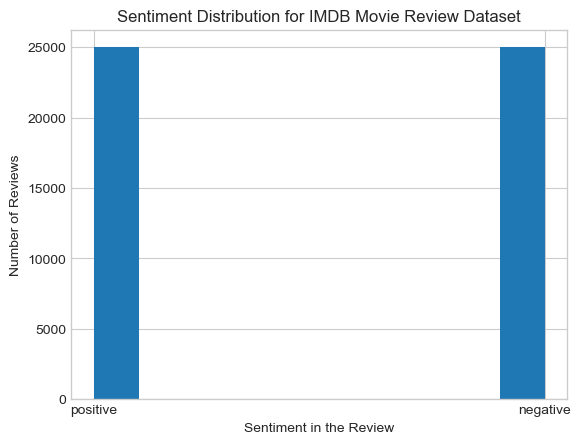

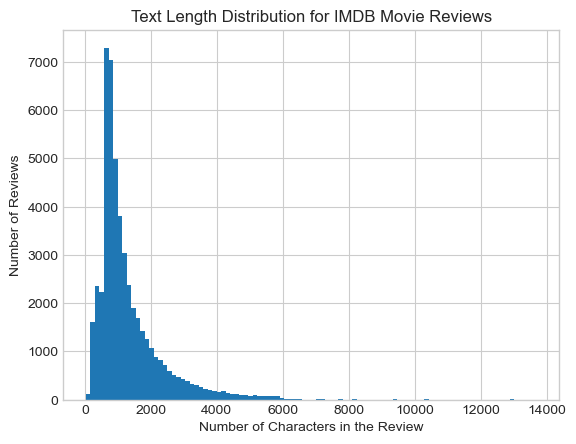

In [152]:
#2.1 Metadata of the Dataset

#2.1.1 Number of rows
#Store the number of rows in a variable
num_rows=len(movie_review_df)

#Print the clear number
print(f"There are {num_rows} in this dataset")

#2.1.2 Columns
movie_review_df.columns
#Column 1 ("review"): This column is made up of strings that are comprised of reviews

#Column 2 ("sentiment"): This column is comprised of strings that either read positive or negative.
movie_review_df['sentiment'].unique()

#2.1.3 Data Types
movie_review_df.dtypes
#Column 1 ("review"): This column is made up of strings
#Column 2 ("sentiment"): This column as it sits right now is made up of strings. If we looked at the code and made some slight adjustments it could be a boolean.

#2.1.4 Missing Values

#There are no missing values in this dataset.
movie_review_df.isna().sum()

#2.1.5 Target Distribution

#The target distribution in this case is balanced. 

#2.2 Class Distribution

#Show a histogram for the distribution of the Sentiment reviews
plt.hist(movie_review_df['sentiment'])
plt.xlabel("Sentiment in the Review")
plt.ylabel("Number of Reviews")
plt.title("Sentiment Distribution for IMDB Movie Review Dataset")
#Save the Figure as a .png file
plt.savefig("sentiment_distribution_hist.png")
plt.show()

#2.2.1 Is the dataset balanced?

#Shows a histogram for the length of the reviews in characters
#Finds the number of characters for each review and stores them in a variable
text_len_hist_data=movie_review_df["review"].str.len()
#Create the histogram with enough bins to show the distribution clearly
plt.hist(text_len_hist_data,bins=100)
plt.xlabel("Number of Characters in the Review")
plt.ylabel("Number of Reviews")
plt.title("Text Length Distribution for IMDB Movie Reviews")
#Save the Figure as a .png file
plt.savefig("text_length_distribution_hist.png")
plt.show()

#Looking at the distribution of review sentiment from the sentiment column, we can see that the distribution is exactly even.

#2.2.2 What is the Majority-to-Minority ratio?

#The Majority-to-Minority ratio in this case is 1:1 because the dataset is balanced.


In [153]:
# STEP 3: Pre-Processing

# =============================================================================
# DATA CLEANING FUNCTION
# =============================================================================

def clean_text_total(text):
    """
    Clean raw text by removing noise.
    
    Steps:
        1. Remove HTML tags (e.g., <p>, <div>, <br>)
        2. Remove URLs (http://, https://, www.)
        3. Remove email addresses
        4. Normalize whitespace (multiple spaces → single space)
    
    Parameters:
        text (str): Raw text string
    
    Returns:
        str: Cleaned text string
    
    Example:
        >>> clean_text("<p>Visit http://example.com or email test@mail.com</p>")
        'Visit or email'
    """
    # Handle missing values
    if pd.isna(text):
        return ""
    
    # Convert to string
    text = str(text)
    
    # Step 1: Remove HTML tags
    # Pattern: <anything> where anything doesn't contain >
    text = re.sub(r'<[^>]+>', '', text)
    
    # Step 2: Remove URLs
    # Pattern: http(s):// or www. followed by non-whitespace
    text = re.sub(r'http\S+|www\.\S+', '', text)
    
    # Step 3: Remove email addresses
    # Pattern: something@something.something
    text = re.sub(r'\S+@\S+', '', text)

    #Step 4: Catch any additional HTML that didn't make it through the initial cleaning steps.
    text= BeautifulSoup(text, "html.parser").get_text()
    
    # Step 4: Normalize whitespace
    # Replace multiple spaces/tabs/newlines with single space
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 5: Expand contractions
    text=contractions.fix(text)

    #Removes Special Characters
    text=re.sub(r'[^a-zA-Z0-9. !?]', ' ', text)
    
    return text

#This function is for the analysis on words themselves instead of as a whole
def remove_punctuation(text):
    text=re.sub(r'[^a-zA-Z0-9 ]', ' ', text)
    return text


In [154]:
movie_review_df['all_in_one_clean']=movie_review_df['review'].apply(clean_text_total)

In [155]:
movie_review_df

,review,sentiment,all_in_one_clean
0,One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked....,positive,One of the other reviewers has mentioned that after watching just 1 Oz episode you will be hooke...
1,A wonderful little production. <br /><br />The filming technique is very unassuming- very old-ti...,positive,A wonderful little production. The filming technique is very unassuming very old time BBC fashi...
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air...",positive,I thought this was a wonderful way to spend time on a too hot summer weekend sitting in the air...
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his...,negative,Basically there is a family where a little boy Jake thinks there is a zombie in his closet h...
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei off...",positive,Petter Mattei s Love in the Time of Money is a visually stunning film to watch. Mr. Mattei off...
...,...,...,...
49995,"I thought this movie did a down right good job. It wasn't as creative or original as the first, ...",positive,I thought this movie did a down right good job. It was not as creative or original as the first ...
49996,"Bad plot, bad dialogue, bad acting, idiotic directing, the annoying porn groove soundtrack that ...",negative,Bad plot bad dialogue bad acting idiotic directing the annoying porn groove soundtrack that ...
49997,"I am a Catholic taught in parochial elementary schools by nuns, taught by Jesuit priests in high...",negative,I am a Catholic taught in parochial elementary schools by nuns taught by Jesuit priests in high...
49998,I'm going to have to disagree with the previous comment and side with Maltin on this one. This i...,negative,I am going to have to disagree with the previous comment and side with Maltin on this one. This ...


In [156]:
nltk.download('stopwords') #need to download this pre-trained data for using with word tokenizer
#
stop_words_nltk = list(stopwords.words('english')) #define English as the stop words

#Create a new column to store the cleaned text
movie_review_df['clean_review_wo_stopwords']=movie_review_df['all_in_one_clean'].copy()

#Go through each review and remove any stopwords that exist.
for review in range(0, len(movie_review_df)):
    a = movie_review_df.clean_review_wo_stopwords[review].split()
    sentence=[ x for x in a  if x.casefold() not in stop_words_nltk]
    movie_review_df['clean_review_wo_stopwords'][review]=" ".join(sentence)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ysass\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [157]:
stop_words_nltk

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [158]:
print(movie_review_df['review'][0])
print(movie_review_df['clean_review_wo_stopwords'][0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [159]:
#Removes punctuation from the cleaned reviews so the can break down common words in the overall popular words per class
movie_review_df['clean_review__wo_sw_or_punc']=movie_review_df['clean_review_wo_stopwords'].apply(remove_punctuation)

In [160]:
movie_review_df

,review,sentiment,all_in_one_clean,clean_review_wo_stopwords,clean_review__wo_sw_or_punc
0,One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked....,positive,One of the other reviewers has mentioned that after watching just 1 Oz episode you will be hooke...,One reviewers mentioned watching 1 Oz episode hooked. right exactly happened me.The first thing ...,One reviewers mentioned watching 1 Oz episode hooked right exactly happened me The first thing ...
1,A wonderful little production. <br /><br />The filming technique is very unassuming- very old-ti...,positive,A wonderful little production. The filming technique is very unassuming very old time BBC fashi...,wonderful little production. filming technique unassuming old time BBC fashion gives comforting ...,wonderful little production filming technique unassuming old time BBC fashion gives comforting ...
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air...",positive,I thought this was a wonderful way to spend time on a too hot summer weekend sitting in the air...,thought wonderful way spend time hot summer weekend sitting air conditioned theater watching lig...,thought wonderful way spend time hot summer weekend sitting air conditioned theater watching lig...
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his...,negative,Basically there is a family where a little boy Jake thinks there is a zombie in his closet h...,Basically family little boy Jake thinks zombie closet parents fighting time.This movie slower so...,Basically family little boy Jake thinks zombie closet parents fighting time This movie slower so...
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei off...",positive,Petter Mattei s Love in the Time of Money is a visually stunning film to watch. Mr. Mattei off...,Petter Mattei Love Time Money visually stunning film watch. Mr. Mattei offers us vivid portrait ...,Petter Mattei Love Time Money visually stunning film watch Mr Mattei offers us vivid portrait ...
...,...,...,...,...,...
49995,"I thought this movie did a down right good job. It wasn't as creative or original as the first, ...",positive,I thought this movie did a down right good job. It was not as creative or original as the first ...,thought movie right good job. creative original first expecting be. whole lotta fun. think like ...,thought movie right good job creative original first expecting be whole lotta fun think like ...
49996,"Bad plot, bad dialogue, bad acting, idiotic directing, the annoying porn groove soundtrack that ...",negative,Bad plot bad dialogue bad acting idiotic directing the annoying porn groove soundtrack that ...,Bad plot bad dialogue bad acting idiotic directing annoying porn groove soundtrack ran continual...,Bad plot bad dialogue bad acting idiotic directing annoying porn groove soundtrack ran continual...
49997,"I am a Catholic taught in parochial elementary schools by nuns, taught by Jesuit priests in high...",negative,I am a Catholic taught in parochial elementary schools by nuns taught by Jesuit priests in high...,Catholic taught parochial elementary schools nuns taught Jesuit priests high school college. sti...,Catholic taught parochial elementary schools nuns taught Jesuit priests high school college sti...
49998,I'm going to have to disagree with the previous comment and side with Maltin on this one. This i...,negative,I am going to have to disagree with the previous comment and side with Maltin on this one. This ...,going disagree previous comment side Maltin one. second rate excessively vicious Western creaks ...,going disagree previous comment side Maltin one second rate excessively vicious Western creaks ...


In [161]:
#Create separated lists so we can make some separation based on classes.
positive_cases=movie_review_df[movie_review_df['sentiment']=='positive']
negative_cases=movie_review_df[movie_review_df['sentiment']=='negative']

In [162]:
def most_popular_words(dataframe):
    words=dataframe['clean_review__wo_sw_or_punc'].str.split()
    all_words=words.explode()
    all_words_standard=all_words.str.lower()
    word_counts=all_words_standard.value_counts()
    top_n_words=word_counts.index[:10]
    return top_n_words

#2.3 Text Analysis by Class

#2.3.1 Average Text length per class 
print(f'The average number of characters in a review (before cleaning) is {movie_review_df['review'].str.len().mean()} characters.')
print(f'The average number of characters in a postive review is {positive_cases['review'].str.len().mean()} characters.')
print(f'The average number of characters in a negative review is {negative_cases['review'].str.len().mean()} characters.')

#2.3.2 Vocabulary
#These reviews contain no emojis, more casual language, language that could be used to heighten emotion (contain emphasis). There are also certain cases where words
#are written in all caps. Depending on the person who wrote it there are some reviews that are more sopisticated in terms of word choice while other people used more 
#simple vocabulary. 

#2.3.3 Common words per class and label
print(f'The top 10 most popular words in positive reviews are {', '.join(most_popular_words(positive_cases))}.')
print(f'The top 10 most popular words in negative reviews are {', '.join(most_popular_words(negative_cases))}.')

The average number of characters in a review (before cleaning) is 1309.43102 characters.
The average number of characters in a postive review is 1324.79768 characters.
The average number of characters in a negative review is 1294.06436 characters.
The top 10 most popular words in positive reviews are film, movie, one, like, good, would, great, story, time, well.
The top 10 most popular words in negative reviews are movie, film, one, like, would, even, good, bad, really, time.


In [142]:
word_counts_positive.head(12)

clean_review__wo_sw_or_punc
film     42090
movie    37843
one      27312
like     17709
good     15020
would    13261
great    12961
story    12932
time     12745
well     12724
see      12271
also     10792
Name: count, dtype: int64

In [144]:
movie_review_df

,review,sentiment,all_in_one_clean,clean_review_wo_stopwords,clean_review__wo_punc_or_punc,clean_review__wo_sw_or_punc
0,One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked....,positive,One of the other reviewers has mentioned that after watching just 1 Oz episode you will be hooke...,One reviewers mentioned watching 1 Oz episode hooked. right exactly happened me.The first thing ...,One reviewers mentioned watching 1 Oz episode hooked right exactly happened me The first thing ...,One reviewers mentioned watching 1 Oz episode hooked right exactly happened me The first thing ...
1,A wonderful little production. <br /><br />The filming technique is very unassuming- very old-ti...,positive,A wonderful little production. The filming technique is very unassuming very old time BBC fashi...,wonderful little production. filming technique unassuming old time BBC fashion gives comforting ...,wonderful little production filming technique unassuming old time BBC fashion gives comforting ...,wonderful little production filming technique unassuming old time BBC fashion gives comforting ...
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air...",positive,I thought this was a wonderful way to spend time on a too hot summer weekend sitting in the air...,thought wonderful way spend time hot summer weekend sitting air conditioned theater watching lig...,thought wonderful way spend time hot summer weekend sitting air conditioned theater watching lig...,thought wonderful way spend time hot summer weekend sitting air conditioned theater watching lig...
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his...,negative,Basically there is a family where a little boy Jake thinks there is a zombie in his closet h...,Basically family little boy Jake thinks zombie closet parents fighting time.This movie slower so...,Basically family little boy Jake thinks zombie closet parents fighting time This movie slower so...,Basically family little boy Jake thinks zombie closet parents fighting time This movie slower so...
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei off...",positive,Petter Mattei s Love in the Time of Money is a visually stunning film to watch. Mr. Mattei off...,Petter Mattei Love Time Money visually stunning film watch. Mr. Mattei offers us vivid portrait ...,Petter Mattei Love Time Money visually stunning film watch Mr Mattei offers us vivid portrait ...,Petter Mattei Love Time Money visually stunning film watch Mr Mattei offers us vivid portrait ...
...,...,...,...,...,...,...
49995,"I thought this movie did a down right good job. It wasn't as creative or original as the first, ...",positive,I thought this movie did a down right good job. It was not as creative or original as the first ...,thought movie right good job. creative original first expecting be. whole lotta fun. think like ...,thought movie right good job creative original first expecting be whole lotta fun think like ...,thought movie right good job creative original first expecting be whole lotta fun think like ...
49996,"Bad plot, bad dialogue, bad acting, idiotic directing, the annoying porn groove soundtrack that ...",negative,Bad plot bad dialogue bad acting idiotic directing the annoying porn groove soundtrack that ...,Bad plot bad dialogue bad acting idiotic directing annoying porn groove soundtrack ran continual...,Bad plot bad dialogue bad acting idiotic directing annoying porn groove soundtrack ran continual...,Bad plot bad dialogue bad acting idiotic directing annoying porn groove soundtrack ran continual...
49997,"I am a Catholic taught in parochial elementary schools by nuns, taught by Jesuit priests in high...",negative,I am a Catholic taught in parochial elementary schools by nuns taught by Jesuit priests in high...,Catholic taught parochial elementary schools nuns taught Jesuit prie

# STEP 3: Text Cleaning and Preprocessing

In this steps, I will detail steps that were made earlier and finalize the text cleaning with any steps I missed earlier. Some of the text cleaning was done earlier in the process so that we can conduct the necessary analysis in EDA (i.e. Most Frequent Words). 

1. Import the text and save it into a dataframe.
2. Create a copy of the column that has the reviews stored in, so we can compare results before and after cleaning.
3. Make sure that all reviews are strings. 
4. Handle any missing values.
5. Removing any HTML tags that are contained within with the reviews
6. Removing any URLs
7. Removing email addresses
8. Removing any additional HTML elements that didn't get caught in steps 5-7.
9. Make sure that the amount of whitespace is the same.
10. Expand any contractions.
11. Removing any special characters
12. Removing Stop Words
13. Remove any punctuation (specifically so we can conduct count of words in each review without punctuation affecting the different tokens).

In [204]:
#Step 3.1. Validation Pipeline

#See above

#Step 3.2 Validation Examples
for i in range(10):
    print(f"Review {[i]}:\n")
    print("------------BEFORE-----------------\n")
    print(movie_review_df['review'][i]+'\n')
    print("------------AFTER-----------------\n")
    print(movie_review_df['clean_review_wo_stopwords'][i]+'\n')

Review [0]:

------------BEFORE-----------------

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would

# STEP 4: Tokenize and Feature Engineer

In this step, I will use multiple tokenization techniques and compare the performance of each out along with feature engineering experiments

In [213]:
def create_tfidf_features(train_texts, test_texts, max_features=5000):
    """
    Create TF-IDF weighted features.
    
    Parameters:
        train_texts (Series/list): Training text documents
        test_texts (Series/list): Test text documents
        max_features (int): Maximum vocabulary size (default: 5000)
    
    Returns:
        tuple: (X_train, X_test, vectorizer)
            - X_train: Sparse matrix of training features
            - X_test: Sparse matrix of test features
            - vectorizer: Fitted TfidfVectorizer object
    
    Example:
        >>> X_train, X_test, vec = create_tfidf_features(train, test)
        >>> print(X_train.shape)  # (n_samples, n_features)
    """
    # Initialize vectorizer
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=(1, 2)
    )
    
    # Fit on training data, transform both
    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)
    
    print(f"TF-IDF:")
    print(f"  Vocabulary size: {len(vectorizer.vocabulary_)}")
    print(f"  Train shape: {X_train.shape}")
    print(f"  Test shape: {X_test.shape}")
    
    return X_train, X_test, vectorizer

In [215]:
def create_count_features(train_texts, test_texts, max_features=5000):
    """
    Create bag-of-words features using CountVectorizer.
    
    Parameters:
        train_texts (Series/list): Training text documents
        test_texts (Series/list): Test text documents
        max_features (int): Maximum vocabulary size (default: 5000)
    
    Returns:
        tuple: (X_train, X_test, vectorizer)
            - X_train: Sparse matrix of training features
            - X_test: Sparse matrix of test features
            - vectorizer: Fitted CountVectorizer object
    
    Example:
        >>> X_train, X_test, vec = create_count_features(train, test)
        >>> print(X_train.shape)  # (n_samples, n_features)
    """
    # Initialize vectorizer
    # ngram_range=(1,2) includes unigrams and bigrams
    vectorizer = CountVectorizer(
        max_features=max_features,
        ngram_range=(1, 2)
    )
    
    # Fit on training data, transform both
    X_train = vectorizer.fit_transform(train_texts)
    X_test = vectorizer.transform(test_texts)
    
    print(f"CountVectorizer:")
    print(f"  Vocabulary size: {len(vectorizer.vocabulary_)}")
    print(f"  Train shape: {X_train.shape}")
    print(f"  Test shape: {X_test.shape}")
    
    return X_train, X_test, vectorizer

In [231]:
def evaluate_binary(y_true, y_pred, pos_label='positive'):
    """
    Evaluate binary classification results.
    
    Parameters:
        y_true: True labels
        y_pred: Predicted labels
        pos_label: Positive class label (default: 'spam')
    
    Returns:
        dict: Dictionary of metrics
    """
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, pos_label=pos_label),
        'Recall': recall_score(y_true, y_pred, pos_label=pos_label),
        'F1': f1_score(y_true, y_pred, pos_label=pos_label)
    }

In [211]:
#Here is where we start to separate the text into training material and texting for the model. 

X_train_movie_review, X_test_movie_review, y_train_movie_review, y_test_movie_review = train_test_split(
    movie_review_df['clean_review_wo_stopwords'],
    movie_review_df['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=movie_review_df['sentiment']  # Maintain class ratio
)

print(f"Training samples: {len(X_train_movie_review)}")
print(f"Test samples: {len(X_test_movie_review)}")

Training samples: 40000
Test samples: 10000


In [221]:
print("\n" + "=" * 60)
print("FEATURE: CountVectorizer")
print("=" * 60)

# Create features
X_train_count, X_test_count, _ = create_count_features(X_train_movie_review, X_test_movie_review)


FEATURE: CountVectorizer
CountVectorizer:
  Vocabulary size: 5000
  Train shape: (40000, 5000)
  Test shape: (10000, 5000)


Naive Bayes | Time: 0.2076s
              precision    recall  f1-score   support

    negative       0.86      0.85      0.85      5000
    positive       0.85      0.87      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



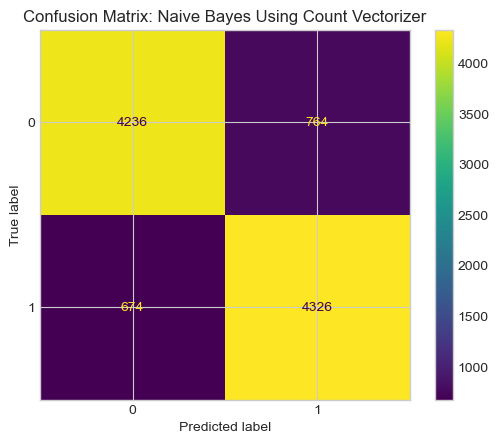

In [261]:
#test with one
nb = MultinomialNB()
start_time = time.time()
nb.fit(X_train_count, y_train_movie_review)
y_pred = nb.predict(X_test_count)
elapsed = time.time() - start_time
print(f"Naive Bayes | Time: {elapsed:.4f}s")
print(classification_report(y_test_movie_review, y_pred))
cm=confusion_matrix(y_test_movie_review, y_pred)
disp=ConfusionMatrixDisplay(cm)
disp.plot()
disp.ax_.set_title("Confusion Matrix: Naive Bayes Using Count Vectorizer")
plt.show()


Training Naive Bayes...
  F1: 0.8575 | Time: 0.5314s
              precision    recall  f1-score   support

    negative       0.86      0.85      0.85      5000
    positive       0.85      0.87      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



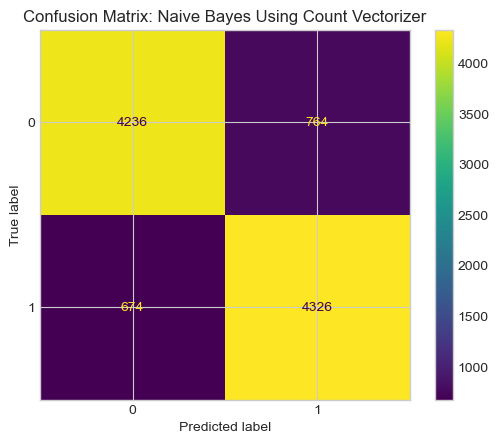

Training Logistic Regression...
  F1: 0.8767 | Time: 3.6621s
              precision    recall  f1-score   support

    negative       0.88      0.87      0.88      5000
    positive       0.88      0.88      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



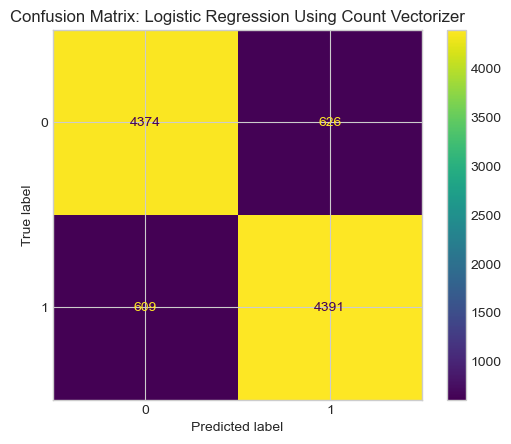

Training SVM...
  F1: 0.8671 | Time: 17.4517s
              precision    recall  f1-score   support

    negative       0.87      0.87      0.87      5000
    positive       0.87      0.87      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



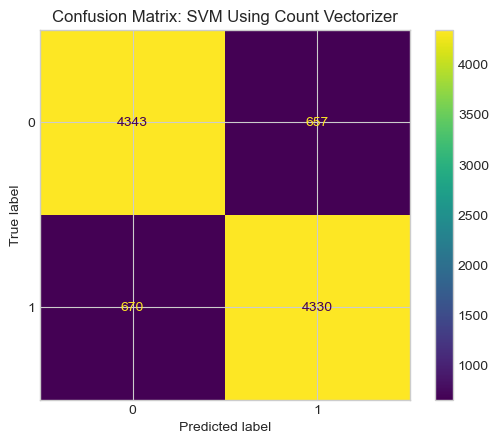

Training Random Forest...
  F1: 0.8510 | Time: 95.8839s
              precision    recall  f1-score   support

    negative       0.85      0.86      0.85      5000
    positive       0.86      0.85      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



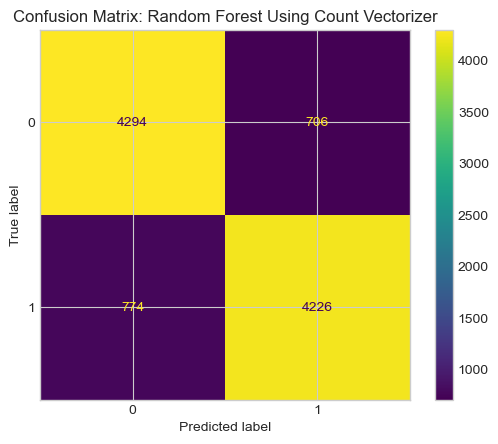


Results:


,Accuracy,Precision,Recall,F1,Train+Predict (s),Feature
Algorithm,,,,,,
Naive Bayes,85.62%,84.99%,86.52%,85.75%,0.531400,CountVectorizer
Logistic Regression,87.65%,87.52%,87.82%,87.67%,3.662100,CountVectorizer
SVM,86.73%,86.83%,86.60%,86.71%,17.451700,CountVectorizer
Random Forest,85.20%,85.69%,84.52%,85.10%,95.883900,CountVectorizer


In [275]:
#combine multiple

# Store results
binary_count_results = []

# Naive Bayes
print("\nTraining Naive Bayes...")
nb = MultinomialNB()
start_time = time.time()
nb.fit(X_train_count, y_train_movie_review)
y_pred = nb.predict(X_test_count)
elapsed = time.time() - start_time
metrics = evaluate_binary(y_test_movie_review, y_pred)
metrics['Train+Predict (s)'] = round(elapsed, 4)
metrics['Algorithm'] = 'Naive Bayes'
binary_count_results.append(metrics)
print(f"  F1: {metrics['F1']:.4f} | Time: {elapsed:.4f}s")
print(classification_report(y_test_movie_review, y_pred))
cm=confusion_matrix(y_test_movie_review, y_pred)
disp=ConfusionMatrixDisplay(cm)
disp.plot()
disp.ax_.set_title("Confusion Matrix: Naive Bayes Using Count Vectorizer")
disp.figure_.savefig('confusion_matrix_nb_count_vectorizer.png')
plt.show()

# Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
start_time = time.time()
lr.fit(X_train_count, y_train_movie_review)
y_pred = lr.predict(X_test_count)
elapsed = time.time() - start_time
metrics = evaluate_binary(y_test_movie_review, y_pred)
metrics['Train+Predict (s)'] = round(elapsed, 4)
metrics['Algorithm'] = 'Logistic Regression'
binary_count_results.append(metrics)
print(f"  F1: {metrics['F1']:.4f} | Time: {elapsed:.4f}s")
print(classification_report(y_test_movie_review, y_pred))
cm=confusion_matrix(y_test_movie_review, y_pred)
disp=ConfusionMatrixDisplay(cm)
disp.plot()
disp.ax_.set_title("Confusion Matrix: Logistic Regression Using Count Vectorizer")
disp.figure_.savefig('confusion_matrix_lr_count_vectorizer.png')
plt.show()

# SVM
print("Training SVM...")
svm = LinearSVC(random_state=42, max_iter=2000)
start_time = time.time()
svm.fit(X_train_count, y_train_movie_review)
y_pred = svm.predict(X_test_count)
elapsed = time.time() - start_time
metrics = evaluate_binary(y_test_movie_review, y_pred)
metrics['Train+Predict (s)'] = round(elapsed, 4)
metrics['Algorithm'] = 'SVM'
binary_count_results.append(metrics)
print(f"  F1: {metrics['F1']:.4f} | Time: {elapsed:.4f}s")
print(classification_report(y_test_movie_review, y_pred))
cm=confusion_matrix(y_test_movie_review, y_pred)
disp=ConfusionMatrixDisplay(cm)
disp.plot()
disp.ax_.set_title("Confusion Matrix: SVM Using Count Vectorizer")
disp.figure_.savefig('confusion_matrix_svm_count_vectorizer.png')
plt.show()

# Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
start_time = time.time()
rf.fit(X_train_count, y_train_movie_review)
y_pred = rf.predict(X_test_count)
elapsed = time.time() - start_time
metrics = evaluate_binary(y_test_movie_review, y_pred)
metrics['Train+Predict (s)'] = round(elapsed, 4)
metrics['Algorithm'] = 'Random Forest'
binary_count_results.append(metrics)
print(f"  F1: {metrics['F1']:.4f} | Time: {elapsed:.4f}s")
print(classification_report(y_test_movie_review, y_pred))
cm=confusion_matrix(y_test_movie_review, y_pred)
disp=ConfusionMatrixDisplay(cm)
disp.plot()
disp.ax_.set_title("Confusion Matrix: Random Forest Using Count Vectorizer")
disp.figure_.savefig('confusion_matrix_rf_count_vectorizer.png')
plt.show()

# Display results
df_count = pd.DataFrame(binary_count_results)
df_count['Feature'] = 'CountVectorizer'
print("\nResults:")
display(df_count.set_index('Algorithm').style.format('{:.2%}', subset=['Accuracy', 'Precision', 'Recall', 'F1']))


FEATURE: TF-IDF
TF-IDF:
  Vocabulary size: 5000
  Train shape: (40000, 5000)
  Test shape: (10000, 5000)

Training Naive Bayes...
  F1: 0.8641 | Time: 0.1987s
              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      5000
    positive       0.85      0.88      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



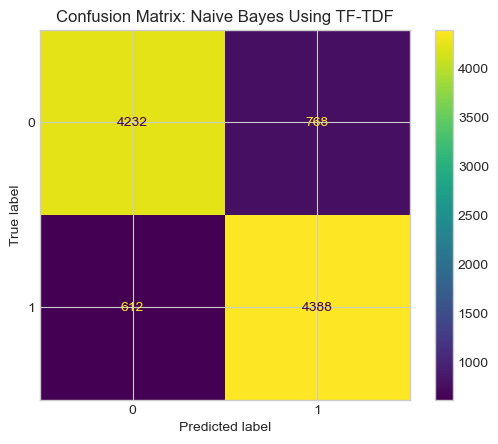

Training Logistic Regression...
  F1: 0.8948 | Time: 0.6002s
              precision    recall  f1-score   support

    negative       0.90      0.89      0.89      5000
    positive       0.89      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



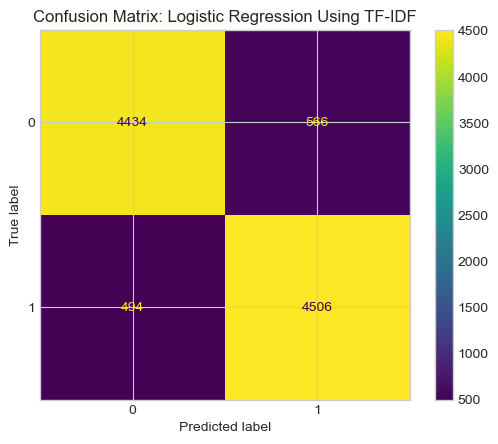

Training SVM...
  F1: 0.8867 | Time: 0.8565s
              precision    recall  f1-score   support

    negative       0.89      0.88      0.89      5000
    positive       0.88      0.89      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



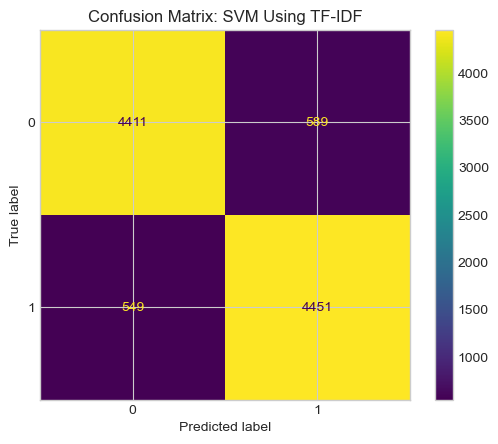

Training Random Forest...
  F1: 0.8503 | Time: 87.2098s
              precision    recall  f1-score   support

    negative       0.84      0.87      0.85      5000
    positive       0.86      0.84      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



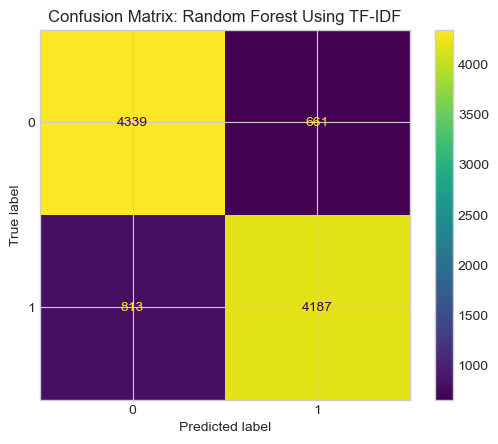


Results:


,Accuracy,Precision,Recall,F1,Train+Predict (s),Feature
Algorithm,,,,,,
Naive Bayes,86.20%,85.10%,87.76%,86.41%,0.198700,TF-IDF
Logistic Regression,89.40%,88.84%,90.12%,89.48%,0.600200,TF-IDF
SVM,88.62%,88.31%,89.02%,88.67%,0.856500,TF-IDF
Random Forest,85.26%,86.37%,83.74%,85.03%,87.209800,TF-IDF


In [277]:
print("\n" + "=" * 60)
print("FEATURE: TF-IDF")
print("=" * 60)

# Create features
X_train_tfidf, X_test_tfidf, _ = create_tfidf_features(X_train_movie_review, X_test_movie_review)

# Store results
binary_tfidf_results = []

# Naive Bayes
print("\nTraining Naive Bayes...")
nb = MultinomialNB()
start_time = time.time()
nb.fit(X_train_tfidf, y_train_movie_review)
y_pred = nb.predict(X_test_tfidf)
elapsed = time.time() - start_time
metrics = evaluate_binary(y_test_movie_review, y_pred)
metrics['Train+Predict (s)'] = round(elapsed, 4)
metrics['Algorithm'] = 'Naive Bayes'
binary_tfidf_results.append(metrics)
print(f"  F1: {metrics['F1']:.4f} | Time: {elapsed:.4f}s")
print(classification_report(y_test_movie_review, y_pred))
cm=confusion_matrix(y_test_movie_review, y_pred)
disp=ConfusionMatrixDisplay(cm)
disp.plot()
disp.ax_.set_title("Confusion Matrix: Naive Bayes Using TF-TDF")
disp.figure_.savefig('confusion_matrix_nb_tfidf.png')
plt.show()

# Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
start_time = time.time()
lr.fit(X_train_tfidf, y_train_movie_review)
y_pred = lr.predict(X_test_tfidf)
elapsed = time.time() - start_time
metrics = evaluate_binary(y_test_movie_review, y_pred)
metrics['Train+Predict (s)'] = round(elapsed, 4)
metrics['Algorithm'] = 'Logistic Regression'
binary_tfidf_results.append(metrics)
print(f"  F1: {metrics['F1']:.4f} | Time: {elapsed:.4f}s")
print(classification_report(y_test_movie_review, y_pred))
cm=confusion_matrix(y_test_movie_review, y_pred)
disp=ConfusionMatrixDisplay(cm)
disp.plot()
disp.ax_.set_title("Confusion Matrix: Logistic Regression Using TF-IDF")
disp.figure_.savefig('confusion_matrix_lr_tfidf.png')
plt.show()

# SVM
print("Training SVM...")
svm = LinearSVC(random_state=42, max_iter=2000)
start_time = time.time()
svm.fit(X_train_tfidf, y_train_movie_review)
y_pred = svm.predict(X_test_tfidf)
elapsed = time.time() - start_time
metrics = evaluate_binary(y_test_movie_review, y_pred)
metrics['Train+Predict (s)'] = round(elapsed, 4)
metrics['Algorithm'] = 'SVM'
binary_tfidf_results.append(metrics)
print(f"  F1: {metrics['F1']:.4f} | Time: {elapsed:.4f}s")
print(classification_report(y_test_movie_review, y_pred))
cm=confusion_matrix(y_test_movie_review, y_pred)
disp=ConfusionMatrixDisplay(cm)
disp.plot()
disp.ax_.set_title("Confusion Matrix: SVM Using TF-IDF")
disp.figure_.savefig('confusion_matrix_svm_tfidf.png')
plt.show()

# Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
start_time = time.time()
rf.fit(X_train_tfidf, y_train_movie_review)
y_pred = rf.predict(X_test_tfidf)
elapsed = time.time() - start_time
metrics = evaluate_binary(y_test_movie_review, y_pred)
metrics['Train+Predict (s)'] = round(elapsed, 4)
metrics['Algorithm'] = 'Random Forest'
binary_tfidf_results.append(metrics)
print(f"  F1: {metrics['F1']:.4f} | Time: {elapsed:.4f}s")
print(classification_report(y_test_movie_review, y_pred))
cm=confusion_matrix(y_test_movie_review, y_pred)
disp=ConfusionMatrixDisplay(cm)
disp.plot()
disp.ax_.set_title("Confusion Matrix: Random Forest Using TF-IDF")
disp.figure_.savefig('confusion_matrix_rf_tfidf.png')
plt.show()

# Display results
df_tfidf = pd.DataFrame(binary_tfidf_results)
df_tfidf['Feature'] = 'TF-IDF'
print("\nResults:")
display(df_tfidf.set_index('Algorithm').style.format('{:.2%}', subset=['Accuracy', 'Precision', 'Recall', 'F1']))

In [267]:
# =============================================================================
# BINARY CLASSIFICATION SUMMARY
# =============================================================================

# Combine all results
binary_all_results = pd.concat([df_count, df_tfidf], ignore_index=True)

print("\n" + "=" * 70)
print("BINARY CLASSIFICATION: COMPLETE RESULTS")
print("=" * 70)

# Pivot table: F1 Scores
binary_pivot = binary_all_results.pivot(index='Algorithm', columns='Feature', values='F1')
binary_pivot = binary_pivot[['CountVectorizer', 'TF-IDF']]

print("\nF1 Scores by Algorithm and Feature Method:")
display(binary_pivot.style.format('{:.2%}').background_gradient(cmap='YlGn', axis=None))

# Pivot table: Training Time
binary_time_pivot = binary_all_results.pivot(index='Algorithm', columns='Feature', values='Train+Predict (s)')
binary_time_pivot = binary_time_pivot[['CountVectorizer', 'TF-IDF']]

print("\n⏱ Train+Predict Time (seconds) by Algorithm and Feature Method:")
display(binary_time_pivot.style.format('{:.4f}').background_gradient(cmap='YlOrRd', axis=None))

# Best combination
best_idx = binary_all_results['F1'].idxmax()
best = binary_all_results.loc[best_idx]
print(f"\n✓ Best combination: {best['Feature']} + {best['Algorithm']} (F1: {best['F1']:.2%})")

# Fastest combination
fastest_idx = binary_all_results['Train+Predict (s)'].idxmin()
fastest = binary_all_results.loc[fastest_idx]
print(f"⚡ Fastest combination: {fastest['Feature']} + {fastest['Algorithm']} ({fastest['Train+Predict (s)']:.4f}s)")


BINARY CLASSIFICATION: COMPLETE RESULTS

F1 Scores by Algorithm and Feature Method:


Feature,CountVectorizer,TF-IDF
Algorithm,,
Logistic Regression,87.67%,89.48%
Naive Bayes,85.75%,86.41%
Random Forest,85.10%,85.03%
SVM,86.71%,88.67%



⏱ Train+Predict Time (seconds) by Algorithm and Feature Method:


Feature,CountVectorizer,TF-IDF
Algorithm,,
Logistic Regression,2.4131,0.5786
Naive Bayes,0.2274,0.2699
Random Forest,97.2461,96.7161
SVM,17.8545,0.7630



✓ Best combination: TF-IDF + Logistic Regression (F1: 89.48%)
⚡ Fastest combination: CountVectorizer + Naive Bayes (0.2274s)


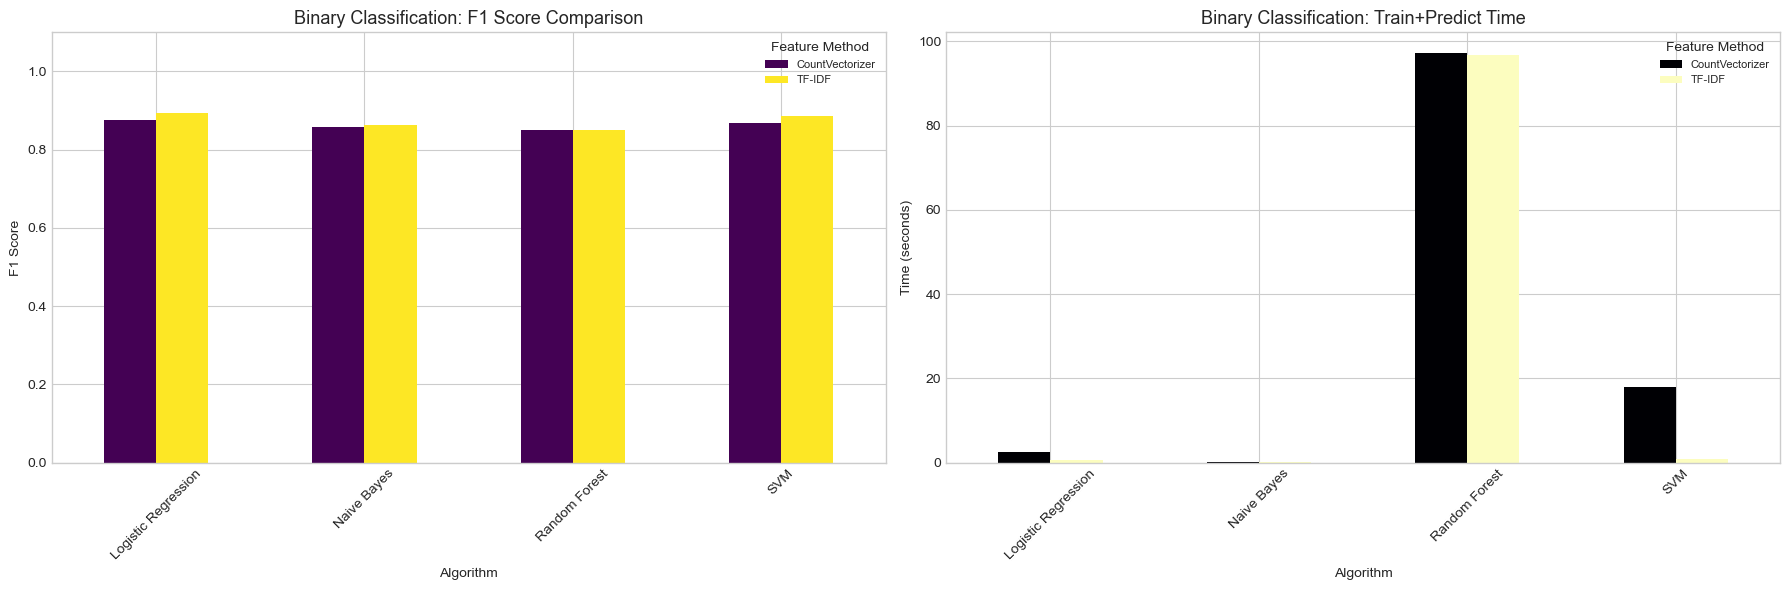

In [273]:
# Visualization: F1 Scores and Timing
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# F1 Score comparison
binary_pivot.plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('Binary Classification: F1 Score Comparison', fontsize=13)
axes[0].set_xlabel('Algorithm')
axes[0].set_ylabel('F1 Score')
axes[0].legend(title='Feature Method', fontsize=8)
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=45)

# Timing comparison
binary_time_pivot.plot(kind='bar', ax=axes[1], colormap='magma')
axes[1].set_title('Binary Classification: Train+Predict Time', fontsize=13)
axes[1].set_xlabel('Algorithm')
axes[1].set_ylabel('Time (seconds)')
axes[1].legend(title='Feature Method', fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("Binary_Classifications_Performance.png")
plt.show()